# Modele 4 - Bilan Carbone (Emissions CO2)

**Cible** : `emissions_train_g_km` (grammes de CO2 par kilometre)
**Modele** : LightGBM (Regression)
**Fichier de sortie** : `modele_LGBM_co2_ULTIMATE.pkl`
**Pipeline** : Chargement par chunks -> Nettoyage / anti-fuite -> Encodage -> Tuning Optuna (echantillon) -> Entrainement final (dataset complet) -> Evaluation -> Sauvegarde


## 1. Imports et configuration

In [2]:
!pip install lightgbm optuna joblib

In [3]:
import gc
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
TARGET = 'emissions_train_g_km'

# Chemin vers le dataset complet (31M+ lignes) - a adapter
CSV_PATH = 'dataset_45M_enrichi_meteo.csv'

print("Imports OK")


Imports OK


## 2. Chargement du dataset complet par chunks

On lit le CSV par blocs de 2M lignes pour limiter le pic memoire. A chaque chunk, on supprime immediatement les colonnes a fuite de donnees et on downcast les types numeriques, avant de concatener.

In [4]:
# Colonnes a EXCLURE des le chargement :
# - co2_saved_vs_car_g_km et reduction_vs_car_pct : calculees DIRECTEMENT a partir de la cible
#   (co2_saved = emissions_car - emissions_train ; reduction_pct = co2_saved / emissions_car * 100)
#   -> Fuite de donnees totale, le modele "trichrait" en inversant la formule.
# - date, timestamp_depart : texte brut redondant (deja decompose en heure/jour_semaine/mois/year)
# - source : metadonnee de collecte (pas une caracteristique du trajet, indisponible en prod)
LEAK_COLS = ['co2_saved_vs_car_g_km', 'reduction_vs_car_pct']
DROP_COLS = LEAK_COLS + ['date', 'timestamp_depart', 'source']

# Colonnes categorielles (texte) du dataset
CAT_COLS = [
    'origin_station', 'destination_station', 'origin_city', 'destination_city',
    'origin_region', 'destination_region', 'service_type', 'flow_type',
    'origin_country_iso', 'destination_country_iso',
    'origin_city_hierarchy', 'destination_city_hierarchy',
    'origin_city_type', 'destination_city_type', 'jour_semaine'
]

CHUNK_SIZE = 2_000_000

def load_full_dataset(path, chunksize=CHUNK_SIZE):
    chunks = []
    t0 = time.time()
    reader = pd.read_csv(path, sep=';', chunksize=chunksize)

    for i, chunk in enumerate(reader):
        # Suppression immediate des colonnes inutiles / a fuite
        chunk = chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns])

        # Downcast des types numeriques pour reduire l'empreinte memoire
        for col in chunk.select_dtypes(include='float64').columns:
            chunk[col] = chunk[col].astype('float32')
        for col in chunk.select_dtypes(include='int64').columns:
            chunk[col] = chunk[col].astype('int32')

        # Colonnes texte -> category (encodage memoire-efficace, gere nativement par LightGBM)
        for col in CAT_COLS:
            if col in chunk.columns:
                chunk[col] = chunk[col].astype('category')

        chunks.append(chunk)
        print(f"Chunk {i+1} charge : {len(chunk):,} lignes (cumul {sum(len(c) for c in chunks):,})")

    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    # Harmonisation des categories sur l'ensemble du dataset
    # (chaque chunk peut avoir vu un sous-ensemble de modalites differentes)
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f"\nChargement termine en {time.time()-t0:.1f}s")
    print(f"Shape finale : {df.shape}")
    print(f"Memoire totale : {df.memory_usage(deep=True).sum() / 1e9:.2f} Go")
    return df

df = load_full_dataset(CSV_PATH)
df.head()


Chunk 1 charge : 2,000,000 lignes (cumul 2,000,000)
Chunk 2 charge : 2,000,000 lignes (cumul 4,000,000)
Chunk 3 charge : 2,000,000 lignes (cumul 6,000,000)
Chunk 4 charge : 2,000,000 lignes (cumul 8,000,000)
Chunk 5 charge : 2,000,000 lignes (cumul 10,000,000)
Chunk 6 charge : 2,000,000 lignes (cumul 12,000,000)
Chunk 7 charge : 2,000,000 lignes (cumul 14,000,000)
Chunk 8 charge : 2,000,000 lignes (cumul 16,000,000)
Chunk 9 charge : 2,000,000 lignes (cumul 18,000,000)
Chunk 10 charge : 2,000,000 lignes (cumul 20,000,000)
Chunk 11 charge : 2,000,000 lignes (cumul 22,000,000)
Chunk 12 charge : 2,000,000 lignes (cumul 24,000,000)
Chunk 13 charge : 2,000,000 lignes (cumul 26,000,000)
Chunk 14 charge : 2,000,000 lignes (cumul 28,000,000)
Chunk 15 charge : 2,000,000 lignes (cumul 30,000,000)
Chunk 16 charge : 2,000,000 lignes (cumul 32,000,000)
Chunk 17 charge : 2,000,000 lignes (cumul 34,000,000)
Chunk 18 charge : 2,000,000 lignes (cumul 36,000,000)
Chunk 19 charge : 2,000,000 lignes (cumul

,year,origin_station,destination_station,origin_city,destination_city,origin_region,destination_region,passengers_millions,service_type,flow_type,...,heure,jour_semaine,mois,est_jour_ferie,lat_origine,lon_origine,lat_destination,lon_destination,temperature_moyenne,pluie_mm
0,2023,Köln Hbf,Stuttgart Hbf,Köln,Stuttgart,Nordrhein-Westfalen,Baden-Württemberg,4.134,Fernverkehr,domestic,...,17,Saturday,6,0,41.274921,0.132065,43.866463,-1.557058,NaN,0.0
1,2023,Arosa,Vendôme,Arosa,Vendôme,Graubünden,Centre-Val de Loire,0.015,International,cross_border,...,16,Tuesday,5,0,46.536793,5.530334,43.066410,3.273367,NaN,0.0
2,2023,Bordeaux Saint-Jean,Paris Montparnasse,Bordeaux,Paris,Nouvelle-Aquitaine,Île-de-France,5.920,TGV/Intercités,domestic,...,9,Monday,9,0,42.367886,6.507569,49.661896,3.220528,NaN,0.0
3,2024,Guingamp,Zermatt,Guingamp,Zermatt,Bretagne,Valais,0.040,International,cross_border,...,5,Thursday,3,0,45.091328,0.279654,46.916672,-3.387045,NaN,0.0
4,2021,Chur,Bordeaux Saint-Jean,Chur,Bordeaux,Graubünden,Nouvelle-Aquitaine,2.590,International,cross_border,...,7,Sunday,10,0,49.274315,5.319215,49.384396,-0.142810,NaN,0.0


## 3. Nettoyage final et separation features / cible

In [5]:
# On retire les lignes ou la cible est manquante (NaN)
n_before = len(df)
df = df.dropna(subset=[TARGET])
print(f"Lignes retirees (cible manquante) : {n_before - len(df):,}")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype('float32')

del df
gc.collect()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"y stats : mean={y.mean():.2f}, std={y.std():.2f}, min={y.min():.2f}, max={y.max():.2f}")

cat_features = [c for c in CAT_COLS if c in X.columns]
print(f"\nFeatures categorielles ({len(cat_features)}) : {cat_features}")
print(f"Features numeriques ({X.shape[1] - len(cat_features)}) : {[c for c in X.columns if c not in cat_features]}")


Lignes retirees (cible manquante) : 474,592
X shape : (44525408, 29)
y shape : (44525408,)
y stats : mean=15.04, std=10.29, min=1.50, max=35.00

Features categorielles (15) : ['origin_station', 'destination_station', 'origin_city', 'destination_city', 'origin_region', 'destination_region', 'service_type', 'flow_type', 'origin_country_iso', 'destination_country_iso', 'origin_city_hierarchy', 'destination_city_hierarchy', 'origin_city_type', 'destination_city_type', 'jour_semaine']
Features numeriques (14) : ['year', 'passengers_millions', 'emissions_car_g_km', 'frequentation_ville_depart_millions', 'frequentation_ville_arrivee_millions', 'heure', 'mois', 'est_jour_ferie', 'lat_origine', 'lon_origine', 'lat_destination', 'lon_destination', 'temperature_moyenne', 'pluie_mm']


## 4. Split Train / Validation / Test (70 / 15 / 15)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=SEED)

del X_temp, y_temp
gc.collect()

print(f"Train : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:,} lignes ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")


Train : 31,166,671 lignes (70.0%)
Val   : 6,679,925 lignes (15.0%)
Test  : 6,678,812 lignes (15.0%)


## 5. Tuning des hyperparametres avec Optuna (sur un echantillon)

Vu la taille du dataset (31M+ lignes), on cherche les meilleurs hyperparametres sur un
**echantillon reduit** (~1M lignes) pour que chaque essai soit rapide. Les parametres trouves
seront ensuite reutilises pour l'entrainement final sur la totalite des donnees.

In [7]:
N_SAMPLE_TUNING = 1_000_000

sample_idx = X_train.sample(n=min(N_SAMPLE_TUNING, len(X_train)), random_state=SEED).index
X_tune = X_train.loc[sample_idx]
y_tune = y_train.loc[sample_idx]

# Sous-split train/val pour l'evaluation de chaque essai Optuna
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune, y_tune, test_size=0.2, random_state=SEED
)

print(f"Echantillon de tuning : {len(X_tune):,} lignes "
      f"(train={len(X_tune_train):,} / val={len(X_tune_val):,})")


Echantillon de tuning : 1,000,000 lignes (train=800,000 / val=200,000)


In [8]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'random_state': SEED,
        'n_jobs': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tune_train, y_tune_train,
        eval_set=[(X_tune_val, y_tune_val)],
        eval_metric='rmse',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    preds = model.predict(X_tune_val, num_iteration=model.best_iteration_)
    rmse = np.sqrt(mean_squared_error(y_tune_val, preds))
    return rmse

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nMeilleur RMSE (echantillon) : {study.best_value:.4f}")
print(f"Meilleurs hyperparametres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/30 [00:00<?, ?it/s]


Meilleur RMSE (echantillon) : 0.4451
Meilleurs hyperparametres :
  n_estimators: 774
  learning_rate: 0.18913898396570583
  num_leaves: 147
  max_depth: 7
  min_child_samples: 94
  subsample: 0.9476421025666553
  colsample_bytree: 0.6506090757484941
  reg_alpha: 9.349337509464321e-07
  reg_lambda: 7.190951612380884e-08


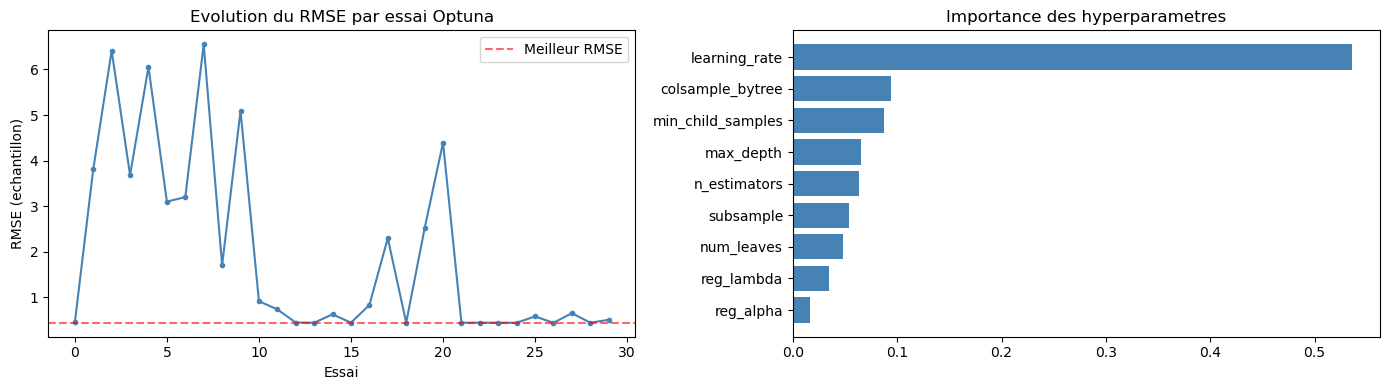

In [9]:
# Historique d'optimisation Optuna
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], marker='o', markersize=3, color='steelblue')
axes[0].axhline(study.best_value, color='red', linestyle='--', alpha=0.6, label='Meilleur RMSE')
axes[0].set_title("Evolution du RMSE par essai Optuna")
axes[0].set_xlabel("Essai")
axes[0].set_ylabel("RMSE (echantillon)")
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_title("Importance des hyperparametres")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 6. Entrainement final sur le dataset complet (31M+ lignes)

In [10]:
best_params = study.best_params.copy()
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': SEED,
    'n_jobs': -1,
})

print("Entrainement du modele final sur l'ensemble Train...")
t0 = time.time()

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

print(f"\nEntrainement termine en {(time.time()-t0)/60:.1f} min")
print(f"Meilleure iteration : {final_model.best_iteration_}")


Entrainement du modele final sur l'ensemble Train...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[774]	valid_0's rmse: 0.377955

Entrainement termine en 5.7 min
Meilleure iteration : 774


## 7. Evaluation sur le jeu de test

In [11]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s} | MAE={mae:.4f} g/km | RMSE={rmse:.4f} g/km | R2={r2:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

y_pred_val  = final_model.predict(X_val,  num_iteration=final_model.best_iteration_)
y_pred_test = final_model.predict(X_test, num_iteration=final_model.best_iteration_)

print("=== Validation ===")
evaluate("LightGBM CO2 (val)", y_val, y_pred_val)
print("\n=== Test (jeu jamais vu) ===")
results_test = evaluate("LightGBM CO2 (test)", y_test, y_pred_test)


=== Validation ===
LightGBM CO2 (val)        | MAE=0.0367 g/km | RMSE=0.3780 g/km | R2=0.9989

=== Test (jeu jamais vu) ===
LightGBM CO2 (test)       | MAE=0.0367 g/km | RMSE=0.3779 g/km | R2=0.9989


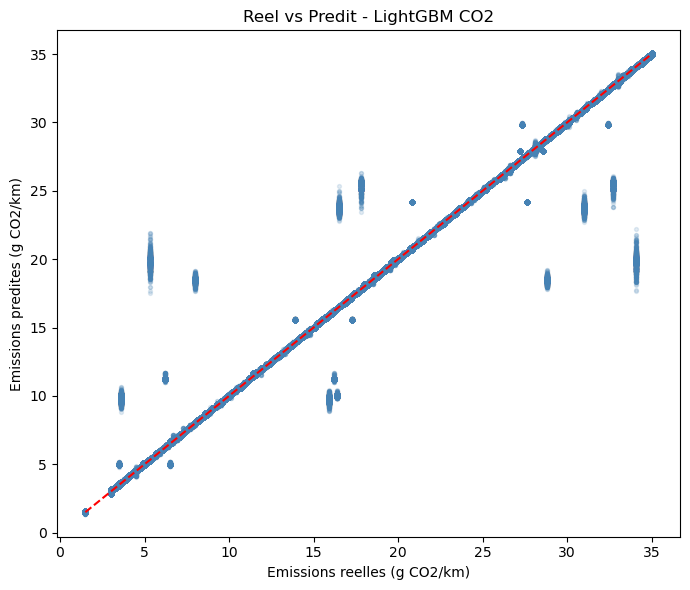

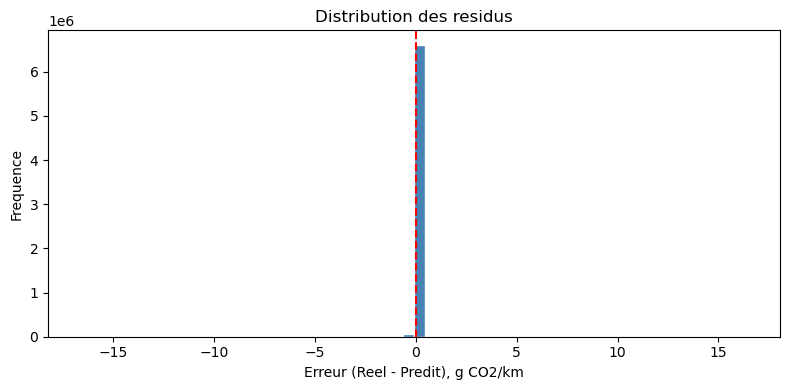

In [12]:
# Reel vs Predit
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.15, s=8, color='steelblue')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5)
plt.xlabel('Emissions reelles (g CO2/km)')
plt.ylabel('Emissions predites (g CO2/km)')
plt.title('Reel vs Predit - LightGBM CO2')
plt.tight_layout()
plt.show()

# Distribution des residus
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution des residus')
plt.xlabel('Erreur (Reel - Predit), g CO2/km')
plt.ylabel('Frequence')
plt.tight_layout()
plt.show()


## 8. Importance des features

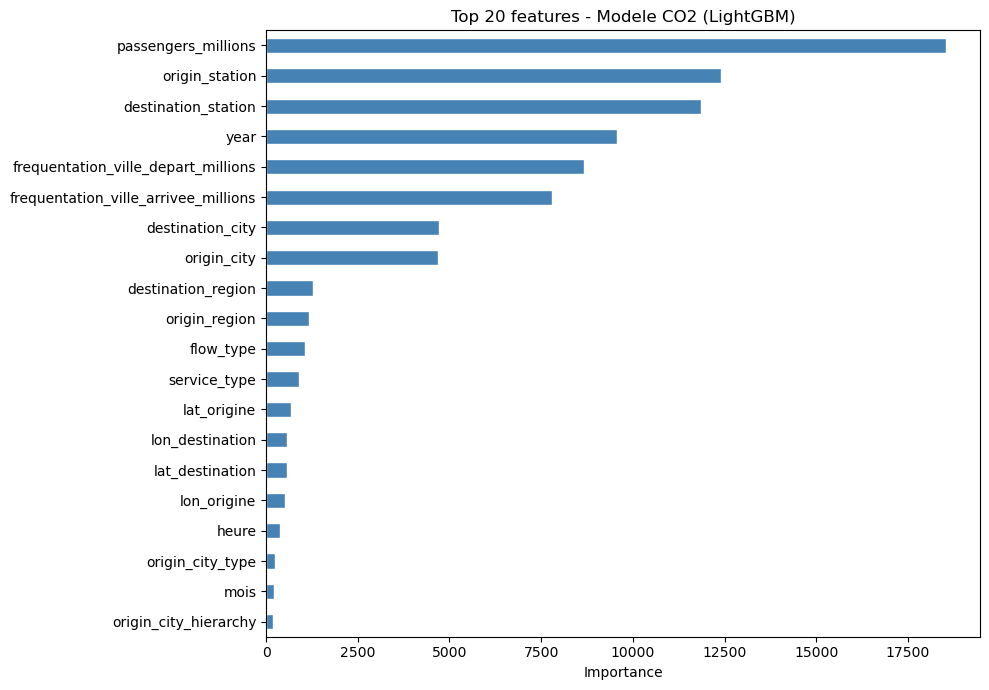

passengers_millions                     18536
origin_station                          12390
destination_station                     11847
year                                     9560
frequentation_ville_depart_millions      8654
frequentation_ville_arrivee_millions     7782
destination_city                         4727
origin_city                              4675
destination_region                       1282
origin_region                            1180
flow_type                                1055
service_type                              902
lat_origine                               691
lon_destination                           582
lat_destination                           567
lon_origine                               521
heure                                     368
origin_city_type                          235
mois                                      210
origin_city_hierarchy                     178
dtype: int32


In [13]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 features - Modele CO2 (LightGBM)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top20)


## 9. Preparation des donnees pour RandomForest (encodage entier)

`RandomForestRegressor` (sklearn) ne sait pas lire le dtype `category` comme LightGBM/XGBoost.
On cree donc une version encodee en entiers (`cat.codes`) des features categorielles,
dans des copies dediees (qu'on supprimera de la memoire une fois RF entraine).

In [14]:
def to_numeric_codes(X):
    """Convertit les colonnes 'category' en codes entiers (int32) pour RandomForest."""
    X_enc = X.copy()
    for col in cat_features:
        X_enc[col] = X_enc[col].cat.codes.astype('int32')
    return X_enc

X_train_rf = to_numeric_codes(X_train)
X_val_rf   = to_numeric_codes(X_val)
X_test_rf  = to_numeric_codes(X_test)

print("Encodage RandomForest termine")
print(f"Memoire X_train_rf : {X_train_rf.memory_usage(deep=True).sum() / 1e9:.2f} Go")


Encodage RandomForest termine
Memoire X_train_rf : 4.95 Go


## 10. Tuning RandomForest avec Optuna (sur le meme echantillon)

On reutilise le meme echantillon de tuning (indices `sample_idx`), encode en entiers.

In [15]:
X_tune_rf = to_numeric_codes(X_tune)
X_tune_train_rf = X_tune_rf.loc[X_tune_train.index]
X_tune_val_rf   = X_tune_rf.loc[X_tune_val.index]

from sklearn.ensemble import RandomForestRegressor

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 8, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_tune_train_rf, y_tune_train)
    preds = model.predict(X_tune_val_rf)
    return np.sqrt(mean_squared_error(y_tune_val, preds))

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

print(f"\nMeilleur RMSE RandomForest (echantillon) : {study_rf.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_rf.best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/20 [00:00<?, ?it/s]


Meilleur RMSE RandomForest (echantillon) : 0.9242
Meilleurs hyperparametres :
  n_estimators: 212
  max_depth: 25
  min_samples_split: 15
  min_samples_leaf: 2
  max_features: 0.30491965894699247


## 11. Entrainement final RandomForest (dataset complet)

In [16]:
best_params_rf = study_rf.best_params.copy()
best_params_rf.update({'random_state': SEED, 'n_jobs': -1})

print("Entrainement RandomForest sur l'ensemble Train...")
t0 = time.time()

final_model_rf = RandomForestRegressor(**best_params_rf)
final_model_rf.fit(X_train_rf, y_train)

print(f"Entrainement termine en {(time.time()-t0)/60:.1f} min")

y_pred_test_rf = final_model_rf.predict(X_test_rf)
print("\n=== Test (jeu jamais vu) ===")
results_test_rf = evaluate("RandomForest CO2 (test)", y_test, y_pred_test_rf)


Entrainement RandomForest sur l'ensemble Train...
Entrainement termine en 42.5 min

=== Test (jeu jamais vu) ===
RandomForest CO2 (test)   | MAE=0.4376 g/km | RMSE=0.8001 g/km | R2=0.9949


## 12. Tuning et entrainement XGBoost

XGBoost (>= 1.5) gere nativement les colonnes `category` (comme LightGBM), via
`enable_categorical=True` + `tree_method='hist'`. Pas besoin de duplication memoire ici :
on reutilise directement `X_train` / `X_val` / `X_test`.

In [17]:
import xgboost as xgb

def objective_xgb(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': SEED,
        'n_jobs': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'early_stopping_rounds': 30,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tune_train, y_tune_train, eval_set=[(X_tune_val, y_tune_val)], verbose=False)
    preds = model.predict(X_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, preds))

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"\nMeilleur RMSE XGBoost (echantillon) : {study_xgb.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/30 [00:00<?, ?it/s]


Meilleur RMSE XGBoost (echantillon) : 0.3334
Meilleurs hyperparametres :
  n_estimators: 697
  learning_rate: 0.06880673101622822
  max_depth: 11
  min_child_weight: 1
  subsample: 0.8650494103543916
  colsample_bytree: 0.8182259632627304
  reg_alpha: 0.0010186553783440569
  reg_lambda: 0.001566360665483835


In [18]:
best_params_xgb = study_xgb.best_params.copy()
best_params_xgb.update({
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
})

print("Entrainement XGBoost sur l'ensemble Train...")
t0 = time.time()

final_model_xgb = xgb.XGBRegressor(**best_params_xgb)
final_model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"Entrainement termine en {(time.time()-t0)/60:.1f} min")
print(f"Meilleure iteration : {final_model_xgb.best_iteration}")

y_pred_test_xgb = final_model_xgb.predict(X_test)
print("\n=== Test (jeu jamais vu) ===")
results_test_xgb = evaluate("XGBoost CO2 (test)", y_test, y_pred_test_xgb)


Entrainement XGBoost sur l'ensemble Train...
Entrainement termine en 22.9 min
Meilleure iteration : 429

=== Test (jeu jamais vu) ===
XGBoost CO2 (test)        | MAE=0.0374 g/km | RMSE=0.3114 g/km | R2=0.9992


## 13. Comparaison des 3 modeles

                  model      MAE     RMSE       R2
    LightGBM CO2 (test) 0.036744 0.377943 0.998857
RandomForest CO2 (test) 0.437630 0.800058 0.994878
     XGBoost CO2 (test) 0.037407 0.311407 0.999224


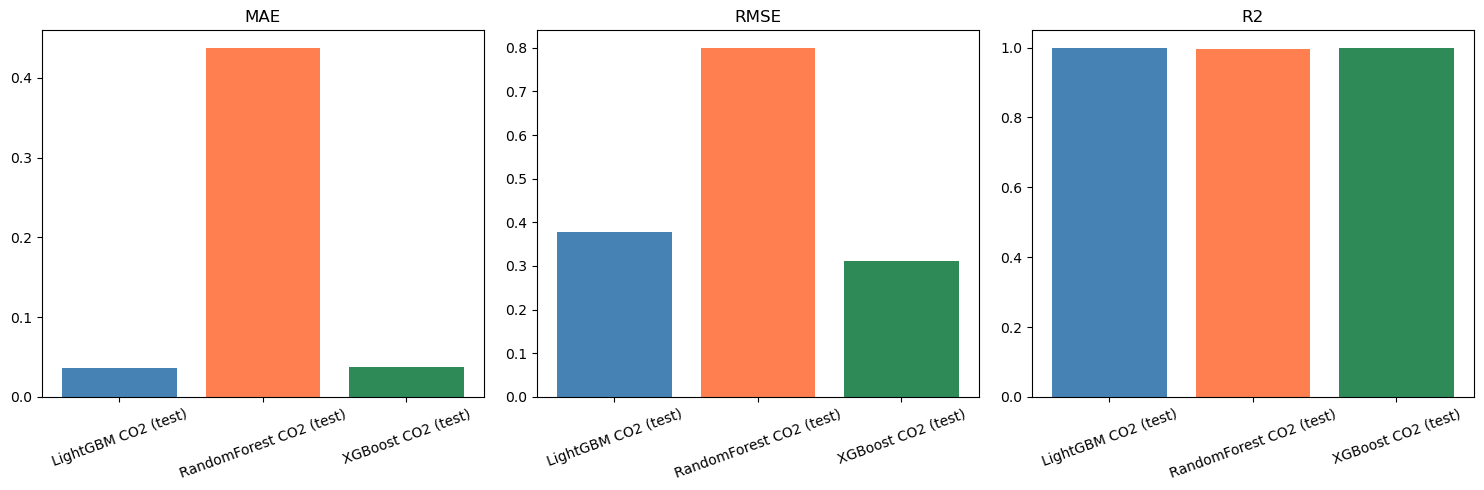


Meilleur modele : XGBoost CO2 (test)


In [19]:
df_compare = pd.DataFrame([results_test, results_test_rf, results_test_xgb])
print(df_compare.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    axes[i].bar(df_compare['model'], df_compare[metric], color=['steelblue', 'coral', 'seagreen'])
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

best_idx = df_compare['R2'].idxmax()
print(f"\nMeilleur modele : {df_compare.loc[best_idx, 'model']}")


## 14. Importance des features (comparaison)

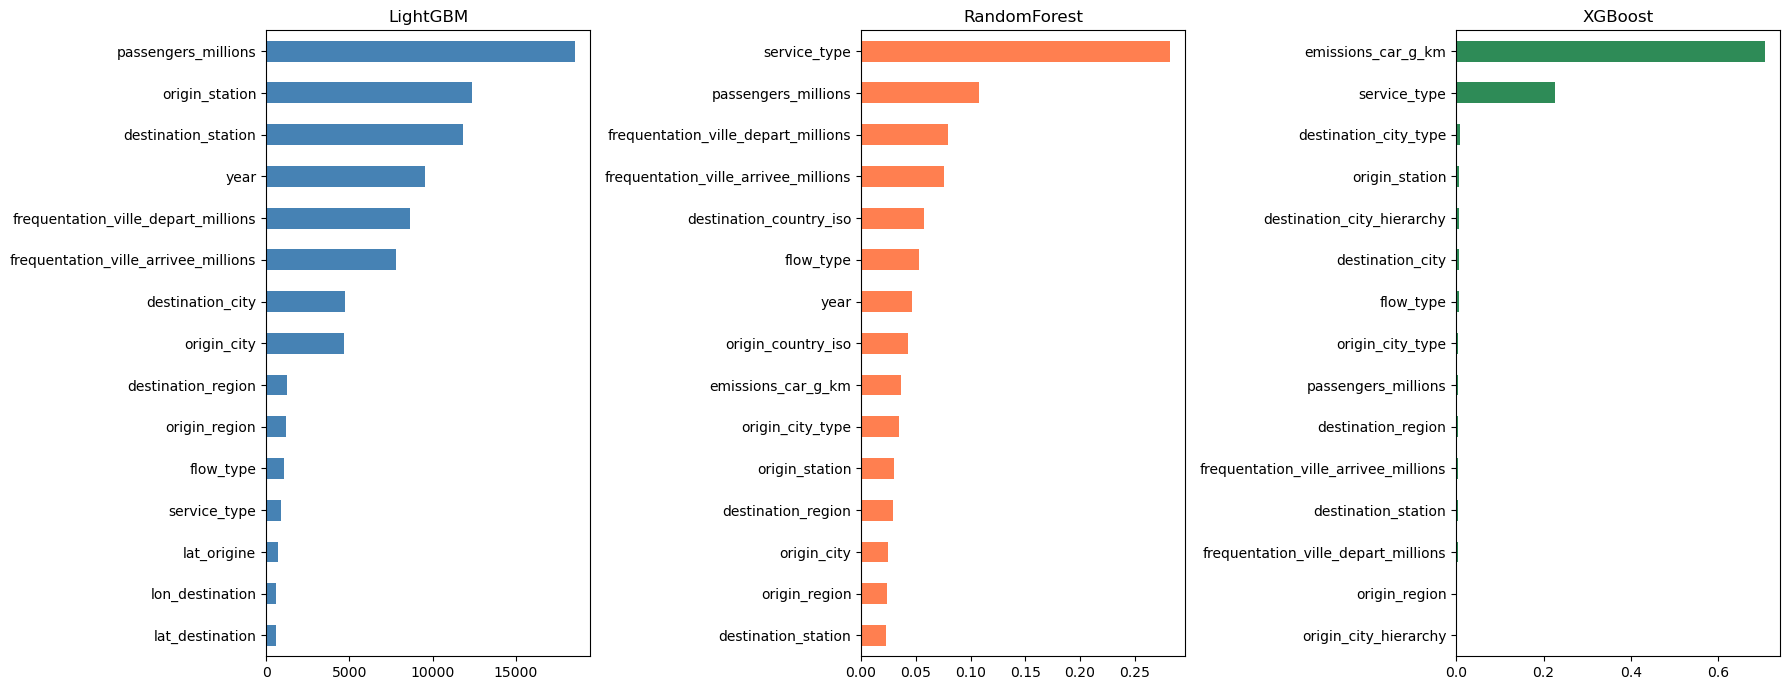

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

imp_lgbm = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
imp_lgbm.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('LightGBM')

imp_rf = pd.Series(final_model_rf.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False).head(15)
imp_rf.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RandomForest')

imp_xgb = pd.Series(final_model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
imp_xgb.sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()


## 15. Sauvegarde des 3 modeles

Chaque modele est sauvegarde avec ses propres metadonnees d'encodage, pour rester
utilisable independamment en production.

In [21]:
# Categories vues a l'entrainement (pour LightGBM/XGBoost - dtype category)
category_mappings = {col: X_train[col].cat.categories.tolist() for col in cat_features}

# Mappings categorie -> code (pour RandomForest - encodage entier)
category_codes_mappings = {
    col: dict(enumerate(X_train[col].cat.categories)) for col in cat_features
}

def save_artifact(path, model, feature_names, extra=None):
    artifact = {
        'model': model,
        'feature_names': feature_names,
        'categorical_features': cat_features,
        'target': TARGET,
    }
    if extra:
        artifact.update(extra)
    joblib.dump(artifact, path)
    print(f"Modele sauvegarde : {path}")

# LightGBM
save_artifact(
    'modele_LGBM_co2_ULTIMATE.pkl', final_model, X_train.columns.tolist(),
    extra={'category_mappings': category_mappings, 'best_params': best_params, 'test_metrics': results_test, 'encoding': 'category'}
)

# RandomForest
save_artifact(
    'modele_RF_co2_ULTIMATE.pkl', final_model_rf, X_train_rf.columns.tolist(),
    extra={'category_codes_mappings': category_codes_mappings, 'best_params': best_params_rf, 'test_metrics': results_test_rf, 'encoding': 'integer_codes'}
)

# XGBoost
save_artifact(
    'modele_XGB_co2_ULTIMATE.pkl', final_model_xgb, X_train.columns.tolist(),
    extra={'category_mappings': category_mappings, 'best_params': best_params_xgb, 'test_metrics': results_test_xgb, 'encoding': 'category'}
)


Modele sauvegarde : modele_LGBM_co2_ULTIMATE.pkl
Modele sauvegarde : modele_RF_co2_ULTIMATE.pkl
Modele sauvegarde : modele_XGB_co2_ULTIMATE.pkl


## 16. Fonction d'inference generique

In [4]:
def predict_co2(new_data: pd.DataFrame, artifact_path: str) -> np.ndarray:
    """
    Calcule l'empreinte CO2 (g/km) pour de nouveaux trajets, quel que soit le modele
    (LightGBM, XGBoost ou RandomForest) sauvegarde a artifact_path.
    """
    art = joblib.load(artifact_path)
    model = art['model']
    feature_names = art['feature_names']
    cat_feats = art['categorical_features']
    data = new_data.copy()

    if art['encoding'] == 'category':
        cat_maps = art['category_mappings']
        for col in cat_feats:
            data[col] = pd.Categorical(data[col], categories=cat_maps[col])
    else:  # integer_codes (RandomForest)
        cat_maps = art['category_codes_mappings']
        for col in cat_feats:
            inv_map = {v: k for k, v in cat_maps[col].items()}
            data[col] = data[col].map(inv_map).fillna(-1).astype('int32')

    data = data[feature_names]
    return model.predict(data)

# Exemple : comparaison des 3 modeles sur les memes lignes
exemple = X_test.head(5)
print("LightGBM     :", np.round(predict_co2(exemple, 'modele_LGBM_co2_ULTIMATE.pkl'), 2))
print("RandomForest :", np.round(predict_co2(exemple, 'modele_RF_co2_ULTIMATE.pkl'), 2))
print("XGBoost      :", np.round(predict_co2(exemple, 'modele_XGB_co2_ULTIMATE.pkl'), 2))
print("Reel         :", y_test.head(5).values)


NameError: name 'X_test' is not defined

## 17. Resume

| Etape | Detail |
|---|---|
| Cible | `emissions_train_g_km` |
| Anti-fuite | Exclusion de `co2_saved_vs_car_g_km` et `reduction_vs_car_pct` (calculees a partir de la cible) |
| Chargement | Lecture par chunks de 2M lignes, downcast des types |
| Encodage | `category` native pour LightGBM/XGBoost, `cat.codes` entiers pour RandomForest |
| Tuning | Optuna sur un echantillon de 1M lignes (30 essais LGBM/XGB, 20 essais RF) |
| Entrainement final | Sur l'integralite du dataset (31M+ lignes) pour les 3 modeles |
| Sauvegarde | `modele_LGBM_co2_ULTIMATE.pkl`, `modele_RF_co2_ULTIMATE.pkl`, `modele_XGB_co2_ULTIMATE.pkl` |

**A noter** : RandomForest est generalement le plus lent et le plus gourmand en memoire
des 3 sur un dataset de cette taille (pas d'early stopping, profondeur d'arbres elevee).
Si l'entrainement RF complet est trop long, reduire `max_depth` ou `n_estimators` dans
`best_params_rf` avant l'entrainement final est la premiere chose a essayer.